In [ ]:
!git clone https://github.com/WegraLee/deep-learning-from-scratch.git

Cloning into 'deep-learning-from-scratch'...
remote: Enumerating objects: 1118, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1118 (delta 142), reused 129 (delta 129), pack-reused 943 (from 2)
Receiving objects: 100% (1118/1118), 52.68 MiB | 40.71 MiB/s, done.
Resolving deltas: 100% (645/645), done.


In [ ]:
import sys
import os

sys.path.append('/content/deep-learning-from-scratch')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from common.trainer import Trainer
from ch07.simple_convnet import SimpleConvNet

In [ ]:
!mkdir -p fashion_mnist

!wget -P fashion_mnist http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz
!wget -P fashion_mnist http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz
!wget -P fashion_mnist http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz
!wget -P fashion_mnist http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz

--2026-05-31 05:11:29--  http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz
Resolving fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)... 52.219.171.92, 52.219.169.224, 3.5.138.251, ...
Connecting to fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)|52.219.171.92|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26421880 (25M) [binary/octet-stream]
Saving to: ‘fashion_mnist/train-images-idx3-ubyte.gz’

train-images-idx3-u 100%[===================>]  25.20M  15.2MB/s    in 1.7s    

2026-05-31 05:11:31 (15.2 MB/s) - ‘fashion_mnist/train-images-idx3-ubyte.gz’ saved [26421880/26421880]

--2026-05-31 05:11:31--  http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz
Resolving fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)... 52.219.1

In [ ]:
import gzip

def load_images(file_path):
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, 1, 28, 28)
    data = data.astype(np.float32) / 255.0
    return data

def load_labels(file_path):
    with gzip.open(file_path, 'rb') as f:
        labels = np.frombuffer(f.read(), np.uint8, offset=8)
    return labels

x_train = load_images('./fashion_mnist/train-images-idx3-ubyte.gz')
t_train = load_labels('./fashion_mnist/train-labels-idx1-ubyte.gz')

x_test = load_images('./fashion_mnist/t10k-images-idx3-ubyte.gz')
t_test = load_labels('./fashion_mnist/t10k-labels-idx1-ubyte.gz')

print(x_train.shape, t_train.shape)
print(x_test.shape, t_test.shape)

(60000, 1, 28, 28) (60000,)
(10000, 1, 28, 28) (10000,)


In [ ]:
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.trainer import Trainer

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
train loss:0.09909500759327942
train loss:0.14005113779547282
train loss:0.09789386237850939
train loss:0.1323812222078165
train loss:0.07271227890076246
train loss:0.14230328896000283
train loss:0.10899176996968302
train loss:0.11396545860485267
train loss:0.16267752509127567
train loss:0.08428643839750558
train loss:0.10870512348403931
train loss:0.13189927092711862
train loss:0.09497147479793588
train loss:0.1514096660318539
train loss:0.07756027385224593
train loss:0.11852738929303713
train loss:0.05263938683601682
train loss:0.12453363839460507
train loss:0.19154354500159304
train loss:0.07720251026485753
train loss:0.17010898411031583
train loss:0.11087952501916237
train loss:0.14108252536831384
train loss:0.07052892901973089
train loss:0.09649036421406575
train loss:0.15343279530159634
train loss:0.12885274636786945
train loss:0.12082161572094131
train loss:0.08733125973189708
train loss:0.0902824635100624
train loss:0.22094282093867243
train 

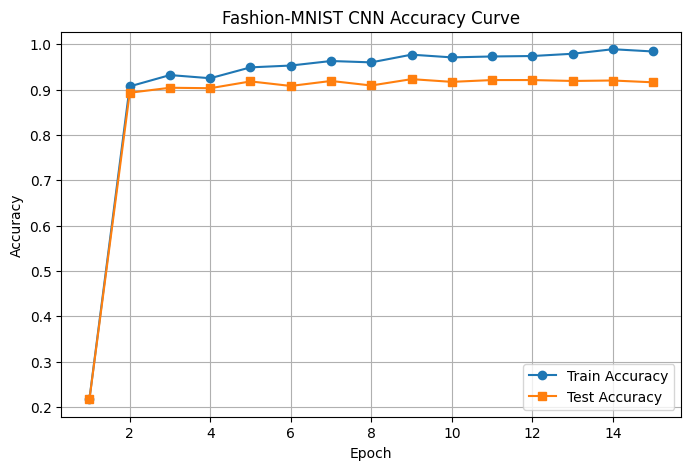

In [ ]:
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt

from common.layers import Convolution, Relu, Pooling, Affine, SoftmaxWithLoss
from common.trainer import Trainer


class TwoConvNet:
    def __init__(self):
        self.params = {}

        self.params['W1'] = np.sqrt(2 / (1 * 3 * 3)) * np.random.randn(32, 1, 3, 3)
        self.params['b1'] = np.zeros(32)

        self.params['W2'] = np.sqrt(2 / (32 * 3 * 3)) * np.random.randn(64, 32, 3, 3)
        self.params['b2'] = np.zeros(64)

        self.params['W3'] = np.sqrt(2 / (64 * 7 * 7)) * np.random.randn(64 * 7 * 7, 256)
        self.params['b3'] = np.zeros(256)

        self.params['W4'] = np.sqrt(2 / 256) * np.random.randn(256, 10)
        self.params['b4'] = np.zeros(10)

        self.layers = OrderedDict()

        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'], stride=1, pad=1)
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)

        self.layers['Conv2'] = Convolution(self.params['W2'], self.params['b2'], stride=1, pad=1)
        self.layers['Relu2'] = Relu()
        self.layers['Pool2'] = Pooling(pool_h=2, pool_w=2, stride=2)

        self.layers['Affine1'] = Affine(self.params['W3'], self.params['b3'])
        self.layers['Relu3'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W4'], self.params['b4'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        acc = 0.0

        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i * batch_size:(i + 1) * batch_size]
            tt = t[i * batch_size:(i + 1) * batch_size]

            y = self.predict(tx)
            y = np.argmax(y, axis=1)

            acc += np.sum(y == tt)

        return acc / x.shape[0]

    def gradient(self, x, t):
        self.loss(x, t)

        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()

        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'] = self.layers['Conv1'].dW
        grads['b1'] = self.layers['Conv1'].db
        grads['W2'] = self.layers['Conv2'].dW
        grads['b2'] = self.layers['Conv2'].db
        grads['W3'] = self.layers['Affine1'].dW
        grads['b3'] = self.layers['Affine1'].db
        grads['W4'] = self.layers['Affine2'].dW
        grads['b4'] = self.layers['Affine2'].db

        return grads


network = TwoConvNet()

trainer = Trainer(
    network,
    x_train,
    t_train,
    x_test,
    t_test,
    epochs=15,
    mini_batch_size=100,
    optimizer='Adam',
    optimizer_param={'lr': 0.0005},
    evaluate_sample_num_per_epoch=1000
)

trainer.train()


train_acc = network.accuracy(x_train, t_train)
test_acc = network.accuracy(x_test, t_test)

print("================================")
print(f"Final Train Accuracy: {train_acc * 100:.2f}%")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print("================================")


plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(trainer.train_acc_list) + 1),
    trainer.train_acc_list,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    np.arange(1, len(trainer.test_acc_list) + 1),
    trainer.test_acc_list,
    marker='s',
    label='Test Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fashion-MNIST CNN Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()